# Notebook 2 - DBSCAN con scikit-learn sobre datos reales

**Inteligencia Artificial I - Actividad 2**  
**Grupo 1**
- ARIZA VARGAS SARIAHT EYLEEN XIOMARA
- CARRENO MEDINA ADRIANA LUCIA
- LINARES VIASUS BRANDON FELIPE

---

## 1. Introducción y Descripción del Problema

### Problema a resolver
Segmentacion de clientes de un centro comercial usando DBSCAN [1] para agrupar por ingreso
anual y spending score, e identificar clientes atipicos que no encajan en ningun segmento.

### Por que DBSCAN
K-Means exige definir cuantos clusters hay antes de correr el modelo. DBSCAN no: encuentra
los grupos a partir de la densidad local y marca como ruido los puntos que no pertenecen a
ninguno [1]. Para segmentacion comercial eso es util porque los outliers pueden representar
comportamiento genuinamente excepcional o errores en los datos.

### Descripcion del dataset
Mall Customers [9], 300 registros, 5 columnas: `CustomerID`, `Genre`, `Age`,
`Annual Income (k$)` y `Spending Score (1-100)`. El spending score es un indice asignado
por el centro comercial segun el historial de compras de cada cliente. El modelo usa solo
las dos ultimas columnas, tras estandarizar con z-score.

## 2. Carga y Exploracion de Datos

Se carga `Mall_Customers.csv` con pandas y se revisa la estructura basica: dimensiones,
tipos de datos y primeras filas. Tambien se verifica que no haya nulos, ya que DBSCAN
calcula distancias y un valor faltante interrumpiria el proceso.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_csv("Mall_Customers.csv")
print("Forma:", df.shape)
df.head()

Forma: (300, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,62,21.50,30.22
1,2,Female,42,36.97,29.09
2,3,Male,34,15.00,11.51
3,4,Male,68,26.13,26.89
4,5,Male,30,21.86,26.99


### 2.2 Tipos de datos y estadísticas descriptivas

`df.info()` confirma los tipos de cada columna y que no hay nulos. `df.describe()` entrega el rango, media y cuartiles de las variables numéricas. Estos valores sirven de referencia para interpretar los histogramas del EDA a continuación.

In [2]:
print(df.info())
print("\nEstadisticas descriptivas:")
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              300 non-null    int64  
 1   Genre                   300 non-null    str    
 2   Age                     300 non-null    int64  
 3   Annual Income (k$)      300 non-null    float64
 4   Spending Score (1-100)  300 non-null    float64
dtypes: float64(2), int64(2), str(1)
memory usage: 11.8 KB
None

Estadisticas descriptivas:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,300.000000,300,300.000000,300.000000,300.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,152,NaN,NaN,NaN
mean,150.500000,NaN,42.376667,59.179700,51.846367
std,86.746758,NaN,15.179686,28.009297,27.932847
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,75.750000,NaN,30.000000,32.217500,25.075000
50%,150.500000,NaN,41.000000,57.730000,51.545000
75%,225.250000,NaN,56.000000,85.070000,78.457500


## 3. Analisis Exploratorio de Datos (EDA)

Se revisan las distribuciones de edad, ingreso anual y spending score, y la distribucion
por genero. Si alguna variable tiene sesgo fuerte o valores extremos, eso distorsiona el
calculo de distancias en DBSCAN. El scatter al final muestra la relacion entre las dos
variables del modelo sin etiquetas, para ver si hay estructura visible antes de correr el
algoritmo.

### 3.1 Histogramas por variable

Cuatro histogramas en cuadrícula 2×2, uno por variable. Edad, ingreso y spending score usan paletas secuenciales distintas (Blues, Greens, Oranges) porque son variables continuas. El gráfico de género usa Set2 porque es una variable categórica.

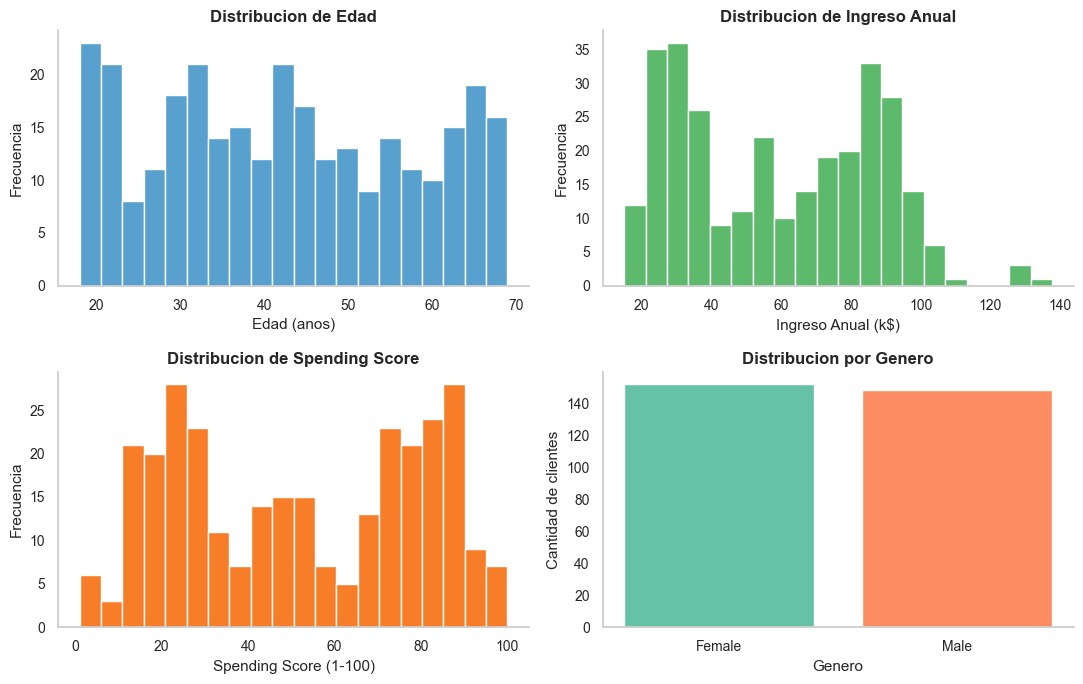

In [3]:
col_age    = sns.color_palette("Blues", 8)[4]   # azul secuencial — Edad
col_income = sns.color_palette("Greens", 8)[4]  # verde secuencial — Ingreso
col_score  = sns.color_palette("Oranges", 8)[4] # naranja secuencial — Score
gender_pal = ["#66C2A5", "#FC8D62"]             # ColorBrewer Set2 — hex exactos

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].hist(df["Age"], bins=20, color=col_age, edgecolor="white")
axes[0, 0].set_title("Distribucion de Edad", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Edad (anos)", fontsize=11)
axes[0, 0].set_ylabel("Frecuencia", fontsize=11)
axes[0, 0].tick_params(labelsize=10)

axes[0, 1].hist(df["Annual Income (k$)"], bins=20, color=col_income, edgecolor="white")
axes[0, 1].set_title("Distribucion de Ingreso Anual", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Ingreso Anual (k$)", fontsize=11)
axes[0, 1].set_ylabel("Frecuencia", fontsize=11)
axes[0, 1].tick_params(labelsize=10)

axes[1, 0].hist(df["Spending Score (1-100)"], bins=20, color=col_score, edgecolor="white")
axes[1, 0].set_title("Distribucion de Spending Score", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Spending Score (1-100)", fontsize=11)
axes[1, 0].set_ylabel("Frecuencia", fontsize=11)
axes[1, 0].tick_params(labelsize=10)

gc = df["Genre"].value_counts()
axes[1, 1].bar(gc.index, gc.values, color=gender_pal, edgecolor="white")
axes[1, 1].set_title("Distribucion por Genero", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Genero", fontsize=11)
axes[1, 1].set_ylabel("Cantidad de clientes", fontsize=11)
axes[1, 1].tick_params(labelsize=10)

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(False)

plt.tight_layout()
plt.show()

### 3.2 Dispersión ingreso vs. spending score

Scatter sin etiquetas para ver la estructura natural de los datos antes de correr DBSCAN. Si hay grupos visibles a ojo, el algoritmo debería detectarlos. No lleva grid porque en un scatter agrega ruido visual sin aportar información (data-ink ratio).

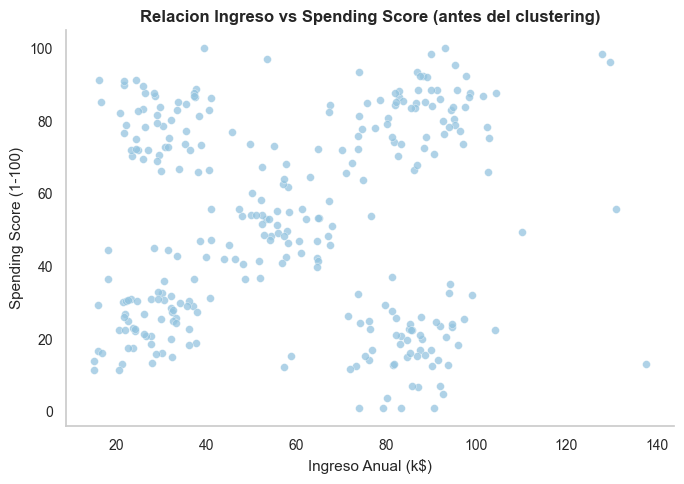

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
           color=sns.color_palette("Blues", 9)[3], s=32, alpha=0.75, edgecolor="white", linewidth=0.3)
ax.set_title("Relacion Ingreso vs Spending Score (antes del clustering)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Ingreso Anual (k$)", fontsize=11)
ax.set_ylabel("Spending Score (1-100)", fontsize=11)
ax.tick_params(labelsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)  # U3: scatter — data-ink ratio
ax.set_facecolor("white")
plt.tight_layout()
plt.show()

### 3.3 Correlaciones entre variables numericas

Matriz de correlacion de Pearson para las tres variables numericas. La paleta `RdBu_r` es
divergente porque la correlacion va de -1 a +1 con cero como punto neutro: azul fuerte es
correlacion negativa, rojo fuerte es positiva. Si dos variables estuvieran muy correlacionadas,
incluirlas juntas en DBSCAN les daria peso doble en el calculo de distancias.

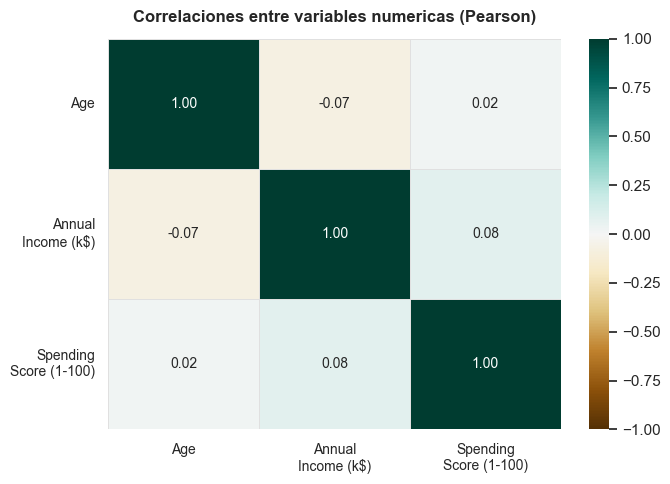


Las correlaciones son bajas: cada variable aporta informacion
independiente. Usar ingreso y spending juntos en DBSCAN es correcto.


In [5]:
corr = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()
labels = ["Age", "Annual\nIncome (k$)", "Spending\nScore (1-100)"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="BrBG",
    vmin=-1, vmax=1, center=0,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="#E0E0E0",
    annot_kws={"fontsize": 10},
    ax=ax
)
ax.set_title("Correlaciones entre variables numericas (Pearson)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10, rotation=0)
ax.tick_params(axis="y", labelsize=10, rotation=0)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout()
plt.show()
print("\nLas correlaciones son bajas: cada variable aporta informacion")
print("independiente. Usar ingreso y spending juntos en DBSCAN es correcto.")

## 4. Preprocesamiento

DBSCAN trabaja con distancias euclidianas [1], así que la variable con mayor rango domina el cálculo si no se escalan los datos. StandardScaler [4] aplica z-score: resta la media y divide por la desviación estándar. Ambas variables quedan con media 0 y desviación 1, y desde ese momento contribuyen por igual.

In [6]:
from sklearn.preprocessing import StandardScaler

# Verificar valores nulos
print("Nulos por columna:\n", df.isna().sum())

# Seleccionar variables para clustering
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values

# Estandarizacion (z-score)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print("\nForma X estandarizado:", X_std.shape)
print("Media:", X_std.mean(axis=0).round(4))
print("Std :", X_std.std(axis=0).round(4))

Nulos por columna:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Forma X estandarizado: (300, 2)
Media: [ 0. -0.]
Std : [1. 1.]


### 4.1 Eleccion de hiperparametros (eps, min_samples)

Para escoger `eps` se usa el **grafico k-distancia** [7]:
1. Calcular la distancia al k-esimo vecino mas cercano para cada punto.
2. Ordenarlas y graficarlas; el "codo" indica el `eps` optimo.

Regla heuristica: `min_samples = 2 * dim` (Schubert et al. 2017 [3]).

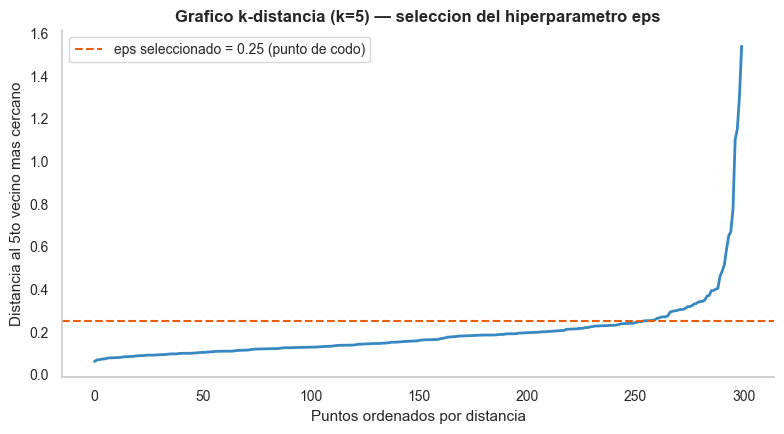

In [7]:
from sklearn.neighbors import NearestNeighbors

k = 5
nn = NearestNeighbors(n_neighbors=k).fit(X_std)
distances, _ = nn.kneighbors(X_std)
kdist = np.sort(distances[:, -1])

# U2: paleta secuencial para la curva principal; acento neutro (naranja) para el codo
# Se evita el rojo porque evoca 'peligro/error' (U2: color con significado)
line_color = sns.color_palette("Blues_d", 3)[1]
codo_color = sns.color_palette("Oranges_d", 3)[1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(len(kdist)), kdist, color=line_color, lw=2)
ax.axhline(0.25, color=codo_color, ls="--", lw=1.5,
           label="eps seleccionado = 0.25 (punto de codo)")
ax.set_title("Grafico k-distancia (k=5) — seleccion del hiperparametro eps",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Puntos ordenados por distancia", fontsize=11)
ax.set_ylabel("Distancia al 5to vecino mas cercano", fontsize=11)
ax.tick_params(labelsize=10)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

## 5. Entrenamiento del Modelo

Se corre DBSCAN con `eps=0.25` y `min_samples=5`, valores seleccionados en la seccion
anterior. `fit_predict` [4][6] recorre todos los puntos y asigna una etiqueta de cluster o el
valor -1 si es ruido. Al final se imprime un resumen con los clusters encontrados y
cuantos puntos quedaron sin asignar.

In [8]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.25, min_samples=5, metric="euclidean")
labels = model.fit_predict(X_std)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))
print(f"Numero de clusters: {n_clusters}")
print(f"Puntos de ruido    : {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print(f"Tamano por cluster:")
for c in sorted(set(labels)):
    name = "ruido" if c == -1 else f"cluster {c}"
    print(f"  {name:>10}: {(labels==c).sum()} puntos")

Numero de clusters: 4
Puntos de ruido    : 20 (6.7%)
Tamano por cluster:
       ruido: 20 puntos
   cluster 0: 114 puntos
   cluster 1: 50 puntos
   cluster 2: 52 puntos
   cluster 3: 64 puntos


## 6. Evaluacion del Modelo (No Supervisado)

En clustering no hay etiqueta correcta para medir el error, así que se usan métricas internas que evalúan la propia estructura de los datos.

El **Silhouette Score** [4] mide qué tan similar es cada punto a su cluster comparado con el más cercano. Va de -1 a 1: valores cercanos a 1 indican clusters compactos y bien separados.

El **Davies-Bouldin Index** [4] relaciona la dispersión interna de cada cluster con la distancia entre clusters. Cuanto más bajo, mejor.

Los puntos de ruido (etiqueta -1) se excluyen de ambas métricas.

In [9]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Silhouette score (excluye ruido)
mask = labels != -1
sil = silhouette_score(X_std[mask], labels[mask])
db  = davies_bouldin_score(X_std[mask], labels[mask])
print(f"Silhouette Score   : {sil:.4f}  (rango [-1, 1], mas alto = mejor separacion)")
print(f"Davies-Bouldin     : {db:.4f}  (mas bajo = mejor)")
print(f"Numero de clusters : {n_clusters}")
print(f"Puntos como ruido  : {n_noise}")

Silhouette Score   : 0.5814  (rango [-1, 1], mas alto = mejor separacion)
Davies-Bouldin     : 0.6167  (mas bajo = mejor)
Numero de clusters : 4
Puntos como ruido  : 20


### 6.1 Visualización de los clusters

La gráfica muestra los cuatro clusters y los 20 puntos de ruido en escala original (no estandarizada), para que los valores en los ejes sean directamente interpretables. Los clusters usan la paleta Set2 de ColorBrewer. El ruido va en equis gris: color y forma distintos, porque depender solo del color es insuficiente para el 8% de personas con daltonismo rojo-verde.

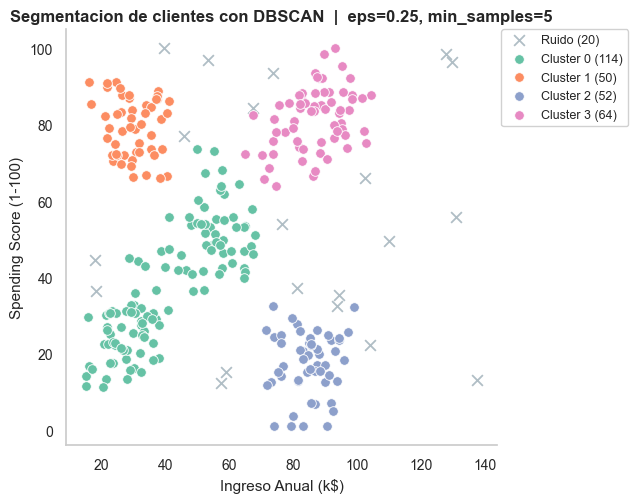

In [10]:
SET2 = ['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3', '#A6D854', '#FFD92F', '#E5C494', '#B3B3B3']

# ColorBrewer Set2 (qualitative) — hex exactos para garantizar reproducibilidad
# Fuente: colorbrewer2.org — accesible para daltonismo rojo-verde (U2)
SET2 = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3",
        "#A6D854", "#FFD92F", "#E5C494", "#B3B3B3"]

fig, ax = plt.subplots(figsize=(8, 5.2))

# Ruido: gris neutro + marcador 'x' (U2: color + forma, no solo color)
for c in sorted(set(labels)):
    mask = labels == c
    if c == -1:
        ax.scatter(X[mask, 0], X[mask, 1],
                   color="#B0BEC5", marker="x", s=60, linewidths=1.3,
                   label=f"Ruido ({mask.sum()})", zorder=2)
    else:
        ax.scatter(X[mask, 0], X[mask, 1],
                   color=SET2[c % len(SET2)], s=48,
                   edgecolor="white", linewidth=0.6,
                   label=f"Cluster {c} ({mask.sum()})", zorder=3)

ax.set_title("Segmentacion de clientes con DBSCAN  |  eps=0.25, min_samples=5",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Ingreso Anual (k$)", fontsize=11)
ax.set_ylabel("Spending Score (1-100)", fontsize=11)
ax.tick_params(labelsize=10)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9,
          bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)  # U3: scatter — data-ink ratio
ax.set_facecolor("white")
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

## 7. Ajuste de Hiperparametros (busqueda en grilla)

Los resultados de DBSCAN cambian bastante según `eps` y `min_samples`. Para explorar el espacio de parámetros se prueba una grilla con cinco valores de `eps` (0.15 a 0.35) y tres de `min_samples` (3, 5, 7). Por cada combinación se registra el número de clusters, la cantidad de ruido y el Silhouette Score [4], calculado solo cuando hay al menos dos clusters. La tabla resultante ayuda a encontrar configuraciones que equilibren la granularidad de los segmentos con la separación entre ellos.

In [11]:
results = []
for eps in [0.15, 0.20, 0.25, 0.30, 0.35]:
    for ms in [3, 5, 7]:
        m = DBSCAN(eps=eps, min_samples=ms).fit(X_std)
        lbl = m.labels_
        nc = len(set(lbl)) - (1 if -1 in lbl else 0)
        nn = int((lbl == -1).sum())
        if nc >= 2:
            sil = silhouette_score(X_std[lbl != -1], lbl[lbl != -1])
        else:
            sil = float("nan")
        results.append({"eps": eps, "min_samples": ms, "n_clusters": nc,
                        "n_noise": nn, "silhouette": round(sil, 4)})

grid_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
grid_df

,eps,min_samples,n_clusters,n_noise,silhouette
4,0.20,5,5,60,0.6850
8,0.25,7,5,32,0.6600
1,0.15,5,7,122,0.6098
2,0.15,7,9,164,0.5901
7,0.25,5,4,20,0.5814
6,0.25,3,4,16,0.5745
11,0.30,7,4,16,0.5709
5,0.20,7,7,85,0.5700
0,0.15,3,12,61,0.4536
9,0.30,3,2,12,0.3698


### 7.1 Análisis de la grilla

La tabla muestra que eps=0.20 con min_samples=5 alcanza el silhouette más alto (0.685), pero a ese precio descarta 60 puntos como ruido, el 20% del dataset. Con eps=0.25 el silhouette baja a 0.581 y el ruido cae a 20 puntos (6.7%). Los 4 clusters que resultan también tienen una lectura comercial más clara que los 5 de eps=0.20, así que la diferencia de 0.10 en silhouette no justifica quedarse con la configuración más agresiva.

## 8. Interpretacion de Resultados

Con los clusters definidos se calcula el perfil promedio de cada segmento: edad media,
ingreso anual medio, spending score medio y numero de clientes. Estos promedios son el
resultado mas util del analisis: muestran que tipo de cliente representa cada grupo y
permiten disenar estrategias distintas para cada uno. Los puntos de ruido se excluyen
porque no pertenecen a ningun segmento.

In [12]:
df["cluster"] = labels
profile = (df[df["cluster"] != -1]
           .groupby("cluster")
           .agg({"Age": "mean", "Annual Income (k$)": "mean",
                 "Spending Score (1-100)": "mean", "CustomerID": "count"})
           .rename(columns={"CustomerID": "n_customers"})
           .round(2))
profile

,Age,Annual Income (k$),Spending Score (1-100),n_customers
cluster,,,,
0,41.28,41.08,37.96,114
1,45.78,29.81,79.36,50
2,42.17,84.77,17.57,52
3,41.66,86.73,81.62,64


### Perfilamiento de los segmentos

Los cuatro clusters tienen perfiles diferenciados segun las medias de ingreso y spending:
bajo ingreso con alto spending (impulsivos), alto ingreso con bajo spending (conservadores),
alto ingreso con alto spending (VIP) y el grupo central de valores medios. Los 20 puntos
de ruido no encajan en ninguno y vale la pena revisarlos individualmente.

### Comparacion con K-Means

A diferencia de K-Means, DBSCAN no asigna los outliers al cluster mas cercano: los separa
y los marca como ruido, dejando los promedios del grupo sin distorsion. Ademas, determino
los 4 segmentos sin que se lo indicaramos.

---

## 9. Conclusiones

DBSCAN identifico 4 segmentos y 20 clientes atipicos en el dataset. El Silhouette Score
de 0.581 indica buena separacion entre los grupos. Los parametros `eps=0.25` y
`min_samples=5` se eligieron con el grafico k-distancia y se confirmaron en la grilla.

El problema mas comun con DBSCAN es su sensibilidad a clusters con densidades muy distintas.
HDBSCAN extiende el algoritmo para manejar ese caso [3]. Como posible extension, se podrian
incluir las demas variables del dataset o comparar los resultados con HDBSCAN.

---

## Referencias (formato IEEE)

[1] M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A density-based algorithm for discovering
clusters in large spatial databases with noise," in *Proc. 2nd Int. Conf. Knowledge Discovery
and Data Mining (KDD-96)*, Portland, OR, USA, 1996, pp. 226-231.

[2] J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "Density-based clustering in spatial
databases: The algorithm GDBSCAN and its applications," *Data Mining and Knowledge Discovery*,
vol. 2, no. 2, pp. 169-194, Jun. 1998.

[3] E. Schubert, J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "DBSCAN revisited, revisited:
why and how you should (still) use DBSCAN," *ACM Transactions on Database Systems*, vol. 42,
no. 3, pp. 1-21, Jul. 2017, doi: 10.1145/3068335.

[4] F. Pedregosa et al., "Scikit-learn: Machine learning in Python," *Journal of Machine
Learning Research*, vol. 12, pp. 2825-2830, Oct. 2011.

[5] T. Hastie, R. Tibshirani, and J. H. Friedman, *The Elements of Statistical Learning*,
2nd ed. New York, NY, USA: Springer, 2009.

[6] Scikit-learn Developers, "sklearn.cluster.DBSCAN," *scikit-learn 1.3 documentation*, 2024.
[Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html.

[7] N. Rahmah and I. S. Sitanggang, "Determination of optimal epsilon (eps) value on DBSCAN
algorithm to clustering data on peatland hotspots in Sumatra," *IOP Conf. Series: Earth and
Environmental Science*, vol. 31, no. 1, p. 012012, 2016.

[8] T. Ali, S. Asghar, and N. A. Sajid, "Critical analysis of DBSCAN variations," in
*Proc. 2010 Int. Conf. Information and Emerging Technologies (ICIET)*, Karachi, Pakistan,
2010, pp. 1-6.

[9] Mall Customers Dataset, *Kaggle*. [Online]. Available:
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python.